In [1]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences
from matplotlib.colors import TwoSlopeNorm

#import networkx as nx # graph visualization of MSM microstates and macrostates model

from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM


# Compared analysis at the lowest resolution level

---
## Prepare data for analysis


Reload data (after clustering)

In [2]:
trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]



total_time_micros = 305
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames


# --------------------------------
# RMSD from crystal distances
# --------------------------------
crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)

rmsd = np.sqrt(np.mean(crystal_dist**2, axis=1))  # [nm]

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003


Fit MSM with previously chosen and validated lagtime

In [3]:
MSM_LAG_NS = 200
MSM_LAG_FRAMES = int(MSM_LAG_NS / time_step_nanos) # 200 ns
print("MSM lag time in frames:", MSM_LAG_FRAMES)
N_CLUSTERS = 30
tce = TransitionCountEstimator(lagtime=MSM_LAG_FRAMES, count_mode="sliding-effective")



msm_dict = {}
micro_trajectory_dict = {} # traj -> micro traj
dtrajs_dict = {} # traj -> micro traj



for i, name in enumerate(trajectories_labels):
    data = np.load(f"../intermediate_outputs/kmeans_plusplus/{N_CLUSTERS}clusters_{name}.npz")
    dtraj = data["traj"].copy()
    centers = data["centers"].copy()
    C = tce.fit(dtraj).fetch_model()
    submodel = C.submodel_largest(directed=True)
    print(f"Submodel for {name} has {submodel.n_states} microstates.")
    micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
    np.save(f"../intermediate_outputs/microstate_trajs/{N_CLUSTERS}clusters_{MSM_LAG_NS}lag_{name}_submodel.npy", micro_trajectory_dict[name])

    dtrajs_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 10000)
    if np.any(dtrajs_dict[name] == -1):
        print(f"Warning: {name} has unassigned microstates after cleaning.")
    msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
    msm_dict[name] = msm

MSM lag time in frames: 1000
Submodel for tica_distances has 30 microstates.
Submodel for pca_distances has 25 microstates.
Submodel for tica_dihedrals has 30 microstates.
Submodel for pca_dihedrals has 30 microstates.


--
# Two-state comparative analysis

Compute microstate PCCA assignments (soft and hard)

In [4]:
n_common = 2

pcca_dict = {}
pcca_memberships_dict = {}
macro_assignments_micro_dict = {}

for name in trajectories_labels:
    msm = msm_dict[name]

    pcca = msm.pcca(n_common)
    pcca_dict[name] = pcca

    # shape: n_microstates x 2
    memberships = pcca.memberships
    pcca_memberships_dict[name] = memberships

    # hard assignment of each microstate
    macro_assignments_micro = memberships.argmax(axis=1)
    macro_assignments_micro_dict[name] = macro_assignments_micro

Project onto the timeseries (soft and hard)

In [5]:
pcca_probabilities_timeseries_dict = {}
hard_assignments_timeseries_dict = {}

for name in trajectories_labels:
    dtraj = dtrajs_dict[name]
    memberships = pcca_memberships_dict[name]


    # probability of belonging to macrostate 1
    p_macro1 = memberships[dtraj, 1]

    # hard macrostate assignment
    hard = np.argmax(memberships[dtraj, :], axis=1)


    pcca_probabilities_timeseries_dict[name] = p_macro1
    hard_assignments_timeseries_dict[name] = hard

Apply coring

In [6]:
def core_two_state_trajectory(hard, min_core_frames):
    """
    hard: array with values 0/1
    min_core_frames: minimum consecutive frames in new state
    """
    hard = np.asarray(hard, dtype=int)
    cored = np.full_like(hard, fill_value=-1)

    current = hard[0]
    cored[0] = current

    i = 1
    while i < len(hard):
        candidate = hard[i]

        if candidate == current:
            cored[i] = current
            i += 1
            continue

        # candidate differs: check whether it persists
        end = i + min_core_frames

        if end <= len(hard) and np.all(hard[i:end] == candidate):
            # accept transition
            current = candidate
            cored[i:end] = current
            i = end
        else:
            # reject as spurious excursion
            cored[i] = current
            i += 1

    # fill any untouched entries
    mask = cored == -1
    cored[mask] = current

    return cored

In [29]:
min_core_markov_steps = 1
min_core_mus = min_core_markov_steps * MSM_LAG_NS / 1000  # convert to microseconds
print("Minimum core time (microseconds):", min_core_mus)
min_core_frames = int(min_core_mus / time_step_micros)

cored_assignments_timeseries_dict = {}

for name in trajectories_labels:
    hard = hard_assignments_timeseries_dict[name]

    cored = core_two_state_trajectory(
        hard,
        min_core_frames=min_core_frames
    )

    cored_assignments_timeseries_dict[name] = cored

Minimum core time (microseconds): 0.2


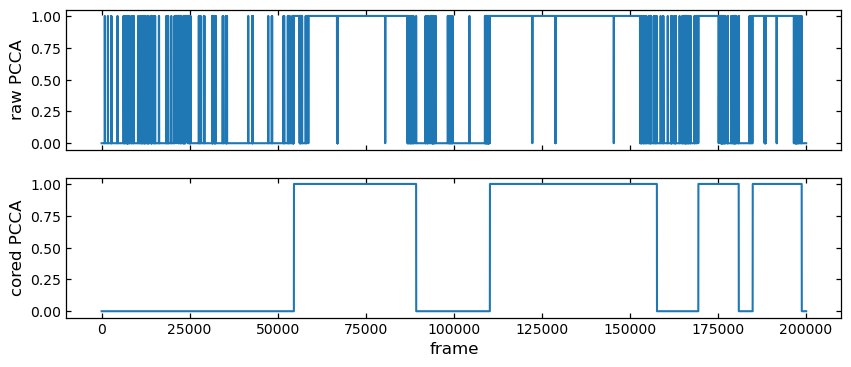

In [30]:
name = trajectories_labels[0]

tmin_mus = 0
tmax_mus = 40

frame_min = int(tmin_mus / time_step_micros)
frame_max = int(tmax_mus / time_step_micros)

x = np.arange(frame_min, frame_max)

fig, axs = plt.subplots(nrows=2, figsize=(10, 4), sharex=True)

axs[0].plot(x, hard_assignments_timeseries_dict[name][frame_min:frame_max])
axs[0].set_ylabel("raw PCCA")

axs[1].plot(x, cored_assignments_timeseries_dict[name][frame_min:frame_max])
axs[1].set_ylabel("cored PCCA")
axs[1].set_xlabel("frame")

plt.show()

Count transitions

In [31]:
def transition_indices(two_state_traj):
    two_state_traj = np.asarray(two_state_traj)
    return np.where(np.diff(two_state_traj) != 0)[0] + 1

In [32]:
transition_indices_dict = {}

for name in trajectories_labels:
    transition_indices_dict[name] = transition_indices(
        cored_assignments_timeseries_dict[name]
    )

In [33]:
def residence_times(two_state_traj, state, time_step_micros):
    """
    Residence times in a given state from a cored 0/1 trajectory.
    Returns times in microseconds.
    """
    traj = np.asarray(two_state_traj, dtype=int)

    change_points = np.where(np.diff(traj) != 0)[0] + 1
    starts = np.r_[0, change_points]
    ends = np.r_[change_points, len(traj)]

    times = []

    for start, end in zip(starts, ends):
        if traj[start] == state:
            duration_frames = end - start
            times.append(duration_frames * time_step_micros)

    return np.asarray(times)

In [34]:
unfolded_state = 0
folded_state = 1

residence_times_unfolded_dict = {}
residence_times_folded_dict = {}

for name in trajectories_labels:
    cored = cored_assignments_timeseries_dict[name]

    residence_times_unfolded_dict[name] = residence_times(
        cored,
        state=unfolded_state,
        time_step_micros=time_step_micros
    )

    residence_times_folded_dict[name] = residence_times(
        cored,
        state=folded_state,
        time_step_micros=time_step_micros
    )

Average waiting time in unfolded basin

In [35]:
for name in trajectories_labels:
    times_U = residence_times_unfolded_dict[name]

    print(name)
    print(f"N unfolded visits: {len(times_U)}")
    print(f"Mean unfolded waiting time: {times_U.mean():.3f} µs")
    print(f"Median unfolded waiting time: {np.median(times_U):.3f} µs")
    print()

tica_distances
N unfolded visits: 24
Mean unfolded waiting time: 3.287 µs
Median unfolded waiting time: 2.733 µs

pca_distances
N unfolded visits: 29
Mean unfolded waiting time: 3.307 µs
Median unfolded waiting time: 1.954 µs

tica_dihedrals
N unfolded visits: 21
Mean unfolded waiting time: 3.856 µs
Median unfolded waiting time: 2.540 µs

pca_dihedrals
N unfolded visits: 23
Mean unfolded waiting time: 3.660 µs
Median unfolded waiting time: 2.789 µs



Pool all trajectories

In [36]:
all_U_times = np.concatenate([
    residence_times_unfolded_dict[name]
    for name in trajectories_labels
])

print(f"Pooled N unfolded visits: {len(all_U_times)}")
print(f"Pooled mean unfolded waiting time: {all_U_times.mean():.3f} µs")
print(f"Pooled median unfolded waiting time: {np.median(all_U_times):.3f} µs")

Pooled N unfolded visits: 97
Pooled mean unfolded waiting time: 3.505 µs
Pooled median unfolded waiting time: 2.540 µs


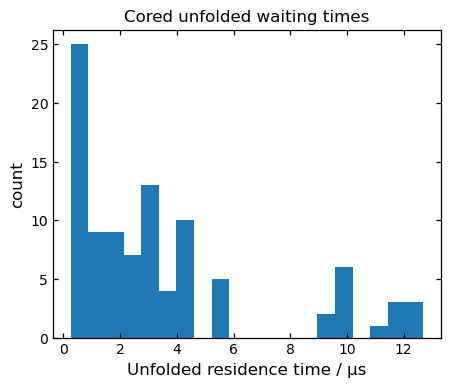

In [37]:
plt.figure(figsize=(5, 4))
plt.hist(all_U_times, bins=20)
plt.xlabel("Unfolded residence time / µs")
plt.ylabel("count")
plt.title("Cored unfolded waiting times")
plt.show()